In [1]:
import sys
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import warnings
from src.probing import HiddenStateExtractor, ProbeManager
device= "cuda" if torch.cuda.is_available() else "cpu"
import warnings
warnings.filterwarnings("ignore")



/Users/Hetansh/Github/research_project_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

# Load probe training data
with open("../data/processed/probe_train.json", 'r') as f:
    probe_data_raw = json.load(f)

# Load forget data (for validation)
with open("../data/processed/forget.json", 'r') as f:
    forget_data = json.load(f)

# FIX: Filter probe data to only use prompts where target is a CITY (not country/language)
# This ensures probe labels match forget data labels
probe_data = [p for p in probe_data_raw if p['target'] == p['city']]

print(f"Probe training set: {len(probe_data)} prompts (filtered from {len(probe_data_raw)})")
print(f"Forget set (for validation): {len(forget_data)} prompts")
print(f"Unique cities in probe data: {len(set(p['city'] for p in probe_data))}")

Probe training set: 37 prompts (filtered from 147)
Forget set (for validation): 59 prompts
Unique cities in probe data: 19


In [3]:
extractor = HiddenStateExtractor(model, tokenizer, device)

print("Extracting hidden states for probe training...")
hidden_states, labels, label_names = extractor.extract_dataset(probe_data)

print(f"\nExtracted data:")
print(f"  - Labels: {len(label_names)} classes")
print(f"  - Sample shape at layer 0: {hidden_states[1].shape}")  # +1 for embedding

Extracting hidden states for probe training...


Extracting hidden states: 100%|██████████| 37/37 [00:00<00:00, 67.30it/s]


Extracted data:
  - Labels: 19 classes
  - Sample shape at layer 0: (37, 768)


In [4]:
num_layers = model.config.n_layer
manager = ProbeManager(num_layers=num_layers, class_names=label_names)
results = manager.train_all_probes(hidden_states, labels)

Training probes:   8%|▊         | 1/12 [00:00<00:03,  2.93it/s]

Layer 0 trained with accuracy: 0.5000, Test = 0.5000


Training probes:  17%|█▋        | 2/12 [00:00<00:03,  3.02it/s]

Layer 1 trained with accuracy: 0.5000, Test = 0.5000


Training probes:  25%|██▌       | 3/12 [00:01<00:03,  2.87it/s]

...

Layer 8 trained with accuracy: 0.5000, Test = 0.5000
Layer 9 trained with accuracy: 0.7500, Test = 0.7500


Training probes:  92%|█████████▏| 11/12 [00:02<00:00,  5.45it/s]

Layer 10 trained with accuracy: 0.7500, Test = 0.7500


Training probes: 100%|██████████| 12/12 [00:03<00:00,  3.36it/s]

Layer 11 trained with accuracy: 0.3750, Test = 0.3750


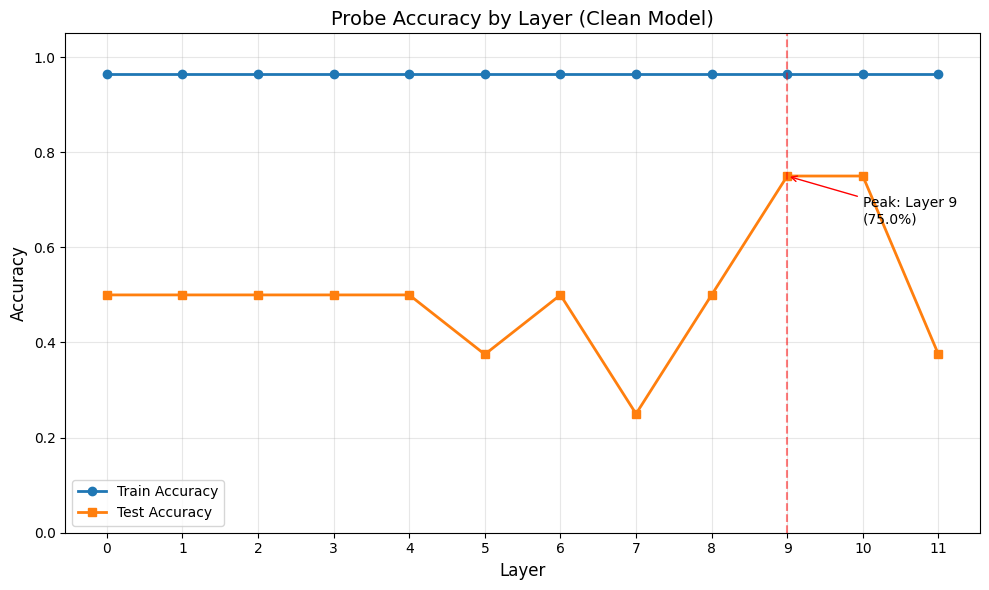


Peak accuracy at Layer 9: 0.750


In [5]:
layers = [r.layer for r in results]
train_accs = [r.train_accuracy for r in results]
test_accs = [r.test_accuracy for r in results]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(layers, train_accs, 'o-', label='Train Accuracy', linewidth=2)
ax.plot(layers, test_accs, 's-', label='Test Accuracy', linewidth=2)
ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Probe Accuracy by Layer (Clean Model)", fontsize=14)
ax.legend()
ax.set_xticks(layers)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Mark peak layer
peak_layer = layers[np.argmax(test_accs)]
peak_acc = max(test_accs)
ax.axvline(x=peak_layer, color='red', linestyle='--', alpha=0.5)
ax.annotate(f'Peak: Layer {peak_layer}\n({peak_acc:.1%})', 
            xy=(peak_layer, peak_acc), xytext=(peak_layer+1, peak_acc-0.1),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig("../figures/probe_accuracy_by_layer.png", dpi=150)
plt.show()

print(f"\nPeak accuracy at Layer {peak_layer}: {peak_acc:.3f}")

In [6]:
print("\nValidating probe generalization to forget prompts...")

# Extract hidden states for forget prompts
forget_hidden, forget_labels, forget_label_names = extractor.extract_dataset(forget_data)

label_to_idx = {name: idx for idx, name in enumerate(label_names)}
forget_labels_mapped = []

for prompt in forget_data:
    if prompt['target'] in label_to_idx:
        forget_labels_mapped.append(label_to_idx[prompt['target']])
    else:
        forget_labels_mapped.append(-1)  # Unknown city

forget_labels_mapped = np.array(forget_labels_mapped)
valid_mask = forget_labels_mapped >= 0
print(f"  Valid forget prompts: {valid_mask.sum()} / {len(forget_data)}")

# Evaluate probes on forget prompts
forget_accuracies = manager.evaluate_on_data(
    {k: v[valid_mask] for k, v in forget_hidden.items()},
    forget_labels_mapped[valid_mask]
)

print("\nProbe accuracy on FORGET prompts (generalization test):")
for layer, acc in sorted(forget_accuracies.items()):
    print(f"  Layer {layer}: {acc:.3f}")


Validating probe generalization to forget prompts...


Extracting hidden states: 100%|██████████| 59/59 [00:00<00:00, 67.90it/s]

  Valid forget prompts: 57 / 59

Probe accuracy on FORGET prompts (generalization test):
  Layer 0: 0.000
  Layer 1: 0.000
  Layer 2: 0.000
  Layer 3: 0.000
  Layer 4: 0.000
  Layer 5: 0.000
  Layer 6: 0.000
  Layer 7: 0.000
  Layer 8: 0.088
  Layer 9: 0.404
  Layer 10: 0.491
  Layer 11: 0.158


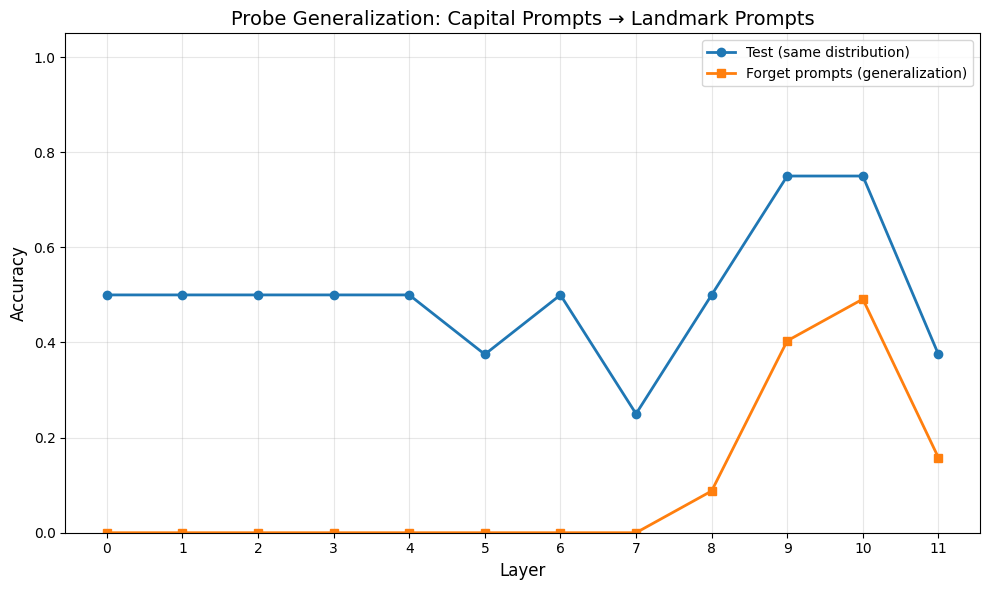

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(layers, test_accs, 'o-', label='Test (same distribution)', linewidth=2)
ax.plot(list(forget_accuracies.keys()), list(forget_accuracies.values()), 
        's-', label='Forget prompts (generalization)', linewidth=2)
ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Probe Generalization: Capital Prompts → Landmark Prompts", fontsize=14)
ax.legend()
ax.set_xticks(layers)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/probe_generalization.png", dpi=150)
plt.show()

In [8]:
manager.save_all("../models/probes")
print("\nProbes saved to ../models/probes/")

# Save results summary
results_summary = {
    'train_accuracies': {r.layer: r.train_accuracy for r in results},
    'test_accuracies': {r.layer: r.test_accuracy for r in results},
    'forget_accuracies': forget_accuracies,
    'peak_layer': int(peak_layer),
    'label_names': label_names
}

with open("../results/probe_training_summary.json", 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Training summary saved!")

Probes saved to ../models/probes

Probes saved to ../models/probes/
Training summary saved!
